In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

REFORM_COLOR = '#12239E'
ACCENT_COLOR = '#E8102A'

print("Imports OK")

Imports OK


In [3]:
df = pd.read_csv('../../data/processed/model_data.csv')

FEATURES = ['leave_vote_share', 'degree_pct', 'median_age', 'median_weekly_wage',
            'claimant_rate', 'foreign_born_pct', 'population_density',
            'ethnic_minority_pct', 'deprivation_score']

feature_labels = {
    'leave_vote_share':    'Brexit Leave vote',
    'degree_pct':          'Degree holders',
    'median_age':          'Median age',
    'median_weekly_wage':  'Median weekly wage',
    'claimant_rate':       'Claimant rate',
    'foreign_born_pct':    'Foreign-born',
    'population_density':  'Population density',
    'ethnic_minority_pct': 'Ethnic minority',
    'deprivation_score':   'Deprivation score',
}

X = df[FEATURES]
y = df['reform_vote_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Champion
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
lr = LinearRegression().fit(X_train_scaled, y_train)

# Challengers (best params from notebook 02)
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
                            min_samples_leaf=5, random_state=42).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                min_samples_leaf=3, random_state=42).fit(X_train, y_train)
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                               min_child_weight=3, random_state=42,
                               verbosity=0).fit(X_train, y_train)

print("All models trained OK")

All models trained OK


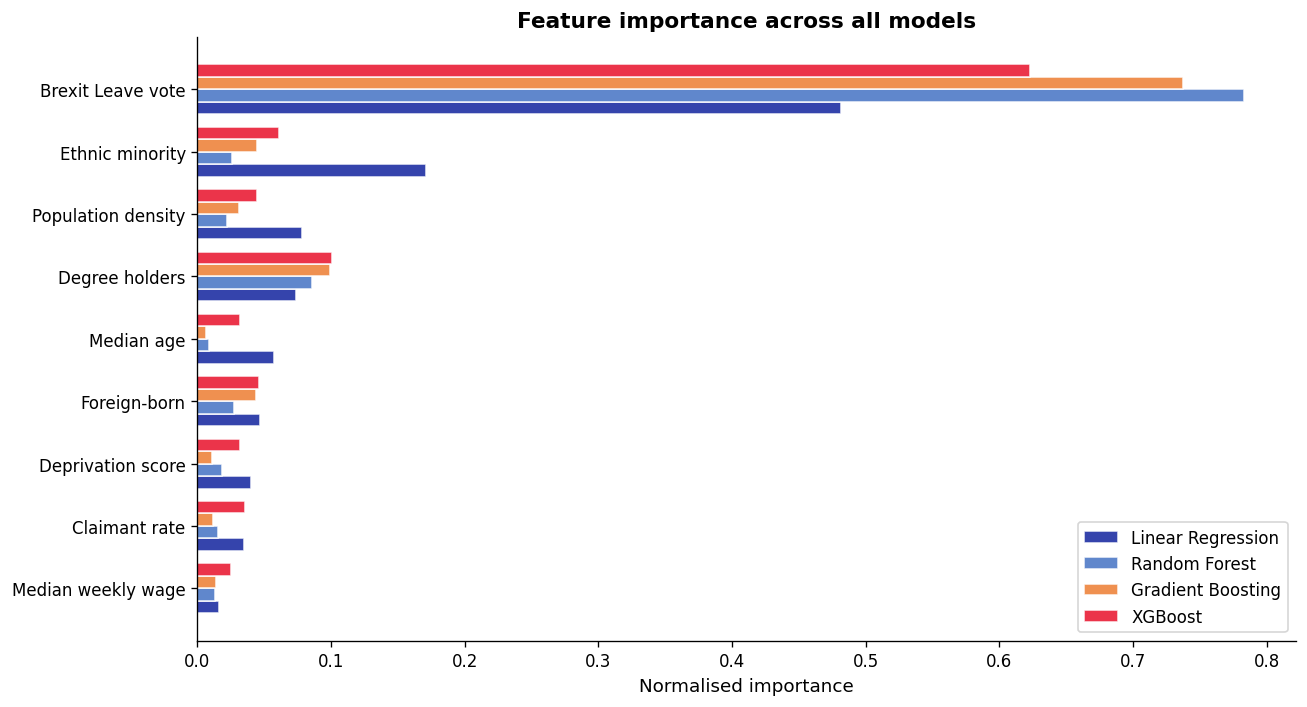

In [4]:
# Linear regression standardised coefficients
lr_coef = pd.Series(np.abs(lr.coef_), index=FEATURES)

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES)

# Gradient Boosting
gb_imp = pd.Series(gb.feature_importances_, index=FEATURES)

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES)

# Normalise all to sum to 1 for fair comparison
def normalise(s): return s / s.sum()

importance_df = pd.DataFrame({
    'Linear Regression': normalise(lr_coef),
    'Random Forest':     normalise(rf_imp),
    'Gradient Boosting': normalise(gb_imp),
    'XGBoost':           normalise(xgb_imp),
}, index=FEATURES)

importance_df.index = [feature_labels[i] for i in importance_df.index]
importance_df = importance_df.sort_values('Linear Regression', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(importance_df))
w = 0.2
colors = [REFORM_COLOR, '#4472C4', '#ED7D31', ACCENT_COLOR]

for i, (col, color) in enumerate(zip(importance_df.columns, colors)):
    ax.barh(x + i*w, importance_df[col], w,
            label=col, color=color, alpha=0.85, edgecolor='white')

ax.set_yticks(x + w*1.5)
ax.set_yticklabels(importance_df.index)
ax.set_xlabel("Normalised importance")
ax.set_title("Feature importance across all models", fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../../outputs/results_01_feature_importance.png', bbox_inches='tight')
plt.show()

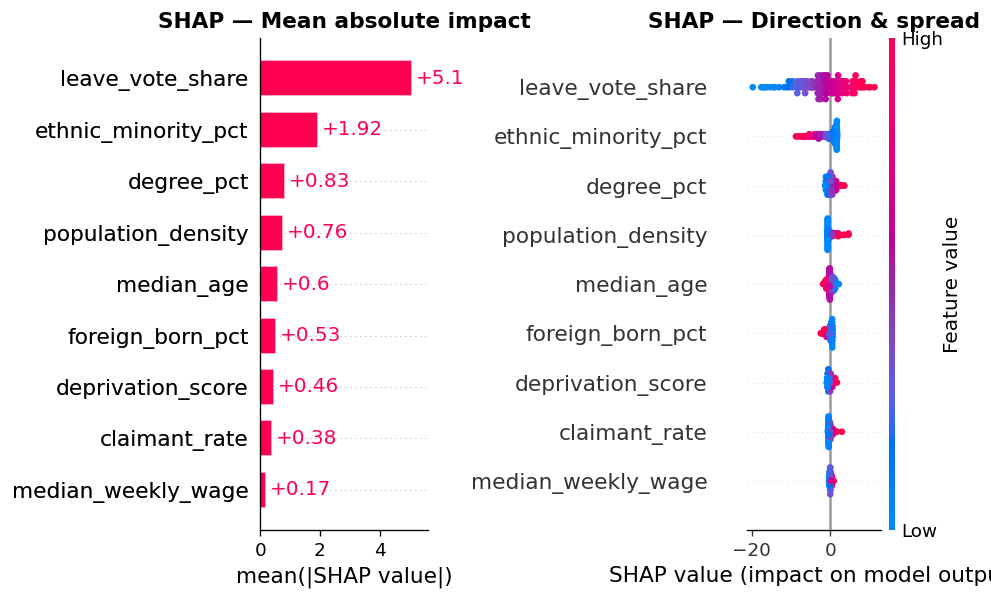

In [5]:
# SHAP on Linear Regression (use unscaled for explainability)
lr_unscaled = LinearRegression().fit(X_train, y_train)

explainer  = shap.LinearExplainer(lr_unscaled, X_train)
shap_values = explainer(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=9, show=False)
axes[0].set_title("SHAP — Mean absolute impact", fontweight='bold')

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, max_display=9, show=False)
axes[1].set_title("SHAP — Direction & spread", fontweight='bold')

plt.tight_layout()
plt.savefig('../../outputs/results_02_shap.png', bbox_inches='tight')
plt.show()

## Results — Data Science Perspective

**Model performance**

All four models achieve comparable R² scores on the test set (0.69–0.77), 
which confirms that Reform UK vote share is genuinely predictable from 
socio-demographic and political variables.

Linear Regression was selected as the champion model based on three criteria:
it achieves the best cross-validated R² (0.667), the lowest overfitting gap 
(0.089), and competitive MAE (2.18 percentage points). The more complex models 
overfit more without mean

## Results — Business & Political Perspective

**Brexit as the defining factor**

The model confirms that the 2024 Reform UK vote is, above all, a continuation 
of the 2016 Brexit vote. Constituencies that voted strongly to Leave have 
consistently shifted their protest vote from UKIP/Brexit Party to Reform UK. 
This suggests Reform's electorate is not primarily new — it is a stable, 
geographically concentrated base that has been building since 2016.

**Education over income**

Contrary to the common narrative that Reform voters are economically 
desperate, median weekly wage has the weakest predictive power of all 
variables. Education level is a much stronger predictor. This aligns with 
research on populist voting across Europe: the key divide is cultural and 
educational, not purely economic.

**The claimant rate paradox**

The claimant rate shows no significant relationship with Reform support 
(r = -0.06, p = 0.134). Areas with high unemployment do not vote more 
Reform — if anything, the opposite. This challenges the idea that Reform 
voters are the most economically marginalised; they appear to be working-class 
but employed, concentrated in post-industrial towns rather than urban 
deprived areas.

**Geographic concentration**

The model's largest errors occur in two types of constituencies: Scottish 
seats (where Reform has little presence) and northern English post-industrial 
towns (Sunderland, Barnsley) where Reform outperforms expectations. This 
points to a regional identity effect the variables do not fully capture.

## Conclusion

This project set out to explain why some UK constituencies vote more for 
Reform UK than others using machine learning.

The results are clear: Reform UK support is strongly predictable (R² = 0.67 
on cross-validation) from a small set of variables, with the 2016 Brexit 
Leave vote accounting for the majority of the effect. Education level is 
the second most important factor, while direct economic hardship indicators 
such as claimant rate show little predictive power.

Linear Regression proved to be the most robust model, outperforming more 
complex ensemble methods on cross-validation. This finding itself is 
meaningful: the drivers of Reform support are largely linear and consistent 
across constituencies, suggesting a stable and structured electoral phenomenon 
rather than a noisy or localised one.

The main limitation of the model is its inability to capture candidate 
availability (Reform did not stand in all constituencies) and local political 
culture effects, particularly in Scotland and parts of northern England.